<a href="https://colab.research.google.com/github/AlxScottt/undergrad_ml_assignments/blob/main/03_assignment_linear_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3: Linear Models

Sources Used: I used chatGPT accseed at https://chatgpt.com/ to help me code greatly during this assigment, and help me reword my descritpions at times.

In [1]:
#this is just the get data stuff, which i copy pasted from the github
import urllib.request
import os
import zipfile
import os

def download_data(force=False):
    """Download and extract course data from Zenodo."""

    zip_path = 'data.zip'
    data_dir = './data'

    if not os.path.exists(zip_path) or force:
        print("Downloading course data...")
        urllib.request.urlretrieve(
            'https://zenodo.org/records/18235955/files/data.zip?download=1',
            zip_path
        )
        print("Download complete")

    if not os.path.exists(data_dir) or force:
        print("Extracting data files...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(data_dir)
        print("Data extracted")

    return data_dir


if __name__ == "__main__":
    download_data()

Download complete
Extracting data files...
Data extracted


**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)
3. Can linear regression be used for classification? Explain why, or why not.
4. What are signs that your linear model is over-fitting?
5. Clearly explain multi-colinearity using the two-stage least squares technique.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
7. What is the interpretation of the slope coefficient in a linear regression?
8. Compare the train/test split and $k$-fold cross validation.
9. How is the $k$ in $k$-fold cross validation typically selected?

1. A model is typically linear when there is a realtonship between the depedent varible and the pararametrs (coeffecitents). Moreover, "linear" in a sense that each term in the model is a constant or a product of a parameter.

2. You look at he coefficients in relation to the intercerpt (or baseline).

3. Not really, classifcation requires discrete class labels while linear regression gueses continous ranging values. (so like classifaction would guess between 0 and 1, and regression could be like -1.5, or 3.)

4. If there is a BIGGG differnce between training and test performance.

5. Multi-colinearity is when two or more predictor varibles are like super corralited. And using two-stage least squares allows us to see that relation in the first instance of estiamtion.

6. Im pretty sure the answer is just linear reggresion.

7. The expected change in your depdent varible for a one unit increase in ur indepent varible.

8. K-fold has less varince since it uses both data from training and testing for validation. Meanwhile train/test split can have superrr high varince depedenig on the size of dataset. K-fold is also more exepsnive.

9. You look at dataset size, amount of desried varaince, most use 5 or 10, smaller datasets you use bigger k values, larger you can go lower, but again most use 5 or 10.


**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

In [3]:
import pandas as pd #import statment

df = pd.read_csv("/content/Q1_clean.csv")

# Rename for convenience (spaces are annoying)
df = df.rename(columns={"Review Scores Rating": "ReviewScore"})

In [6]:
df.head()

,Price,ReviewScore,Neighbourhood,Property Type,Room Type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt


In [13]:
#1
grouped = df.groupby("Neighbourhood ").agg({
    "Price": "mean",
    "ReviewScore": "mean"
})

print(grouped.sort_values("Price", ascending=False))

                     Price  ReviewScore
Neighbourhood                          
Manhattan       183.664286    91.801496
Staten Island   146.166667    90.843750
Brooklyn        127.747378    92.363497
Queens           96.857233    91.549057
Bronx            75.276498    91.654378


Evidently. Manhattan is the most expesnive (which makes sense lol)

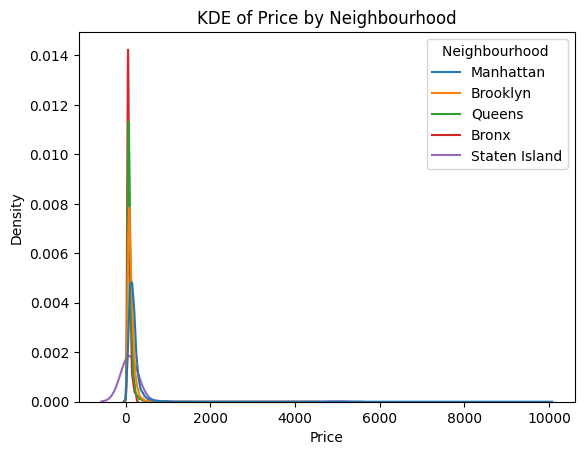

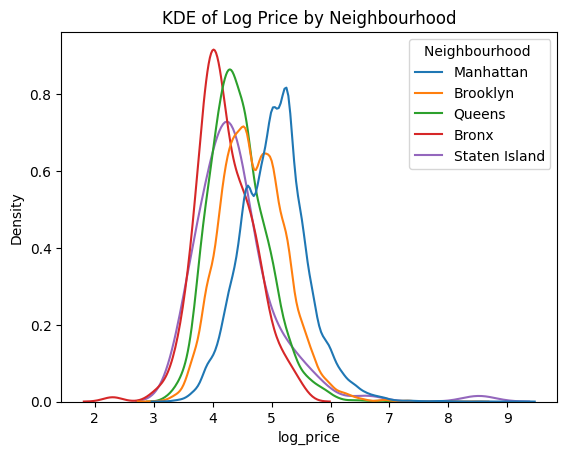

In [15]:
#1 the actual plots
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Price KDE
sns.kdeplot(data=df, x="Price", hue="Neighbourhood ", common_norm=False)
plt.title("KDE of Price by Neighbourhood")
plt.show()

# Log price
df["log_price"] = np.log(df["Price"])

sns.kdeplot(data=df, x="log_price", hue="Neighbourhood ", common_norm=False)
plt.title("KDE of Log Price by Neighbourhood")
plt.show()

In [19]:
df.columns = df.columns.str.strip() #cause the column naming issue was being wierd (neighboruhood extra space, and wouldent just work if i added a space)

In [20]:
import statsmodels.formula.api as smf

model1 = smf.ols("Price ~ C(Neighbourhood)", data=df).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     268.9
Date:                Sat, 21 Mar 2026   Prob (F-statistic):          4.43e-226
Time:                        17:25:52   Log-Likelihood:            -1.4174e+05
No. Observations:               22153   AIC:                         2.835e+05
Df Residuals:                   22148   BIC:                         2.835e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

#2
In this regression, the omitted (baseline) category is the Bronx, so the intercept represents the average price in the Bronx, which is approximately $75.28. (rounded up lol) The coefficients on the neighborhood dummy variables represent differences in average price relative to the Bronx: you can see how much more they cost more on average with the number next to it.

These coefficients correspond directly to the differences in group means computed earlier. Specifically, each coefficient equals the difference between that neighborhood’s average price and the Bronx average price.

In [21]:
model2 = smf.ols("Price ~ ReviewScore", data=df).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     81.92
Date:                Sat, 21 Mar 2026   Prob (F-statistic):           1.53e-19
Time:                        17:29:25   Log-Likelihood:            -1.4222e+05
No. Observations:               22153   AIC:                         2.844e+05
Df Residuals:                   22151   BIC:                         2.845e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      60.8784     10.423      5.841      

#3
The regression of price on review score shows a coefficient of 1.02, meaning that a one-point increase in review score is associated with about a $1.02 increase in nightly price. This indicates a positive relationship!! although its not a very big one cause the r-squared is like mega tinyyy.

In [22]:
model3 = smf.ols("Price ~ C(Neighbourhood) + ReviewScore", data=df).fit()
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     235.3
Date:                Sat, 21 Mar 2026   Prob (F-statistic):          1.21e-245
Time:                        17:29:46   Log-Likelihood:            -1.4169e+05
No. Observations:               22153   AIC:                         2.834e+05
Df Residuals:                   22147   BIC:                         2.834e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

#4 (used chat to clean up my wording grealty)
When both Neighborhood and Review Score are included in the regression, the coefficient on Review Score increases slightly from about 1.02 to 1.08. This means that, holding neighborhood constant, a one-point increase in review score is associated with approximately a $1.08 increase in nightly price.
There is a little bonus when u include the review score.

The neighborhood coefficients change only minimally compared to the model without review scores, indicating that differences in average prices across neighborhoods are largely independent of review scores.

Finally, the R-squared increases slightly (from 0.046 to 0.050), showing that adding review scores improves the model, but only modestly.

In [23]:
model4 = smf.ols("Price ~ C(Neighbourhood) * ReviewScore", data=df).fit()
print(model4.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                  0.067
Method:                 Least Squares   F-statistic:                     178.4
Date:                Sat, 21 Mar 2026   Prob (F-statistic):               0.00
Time:                        17:29:54   Log-Likelihood:            -1.4149e+05
No. Observations:               22153   AIC:                         2.830e+05
Df Residuals:                   22143   BIC:                         2.831e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                                    coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------

#5
When allowing for separate slopes by neighborhood, the effect of review scores on price is generally similar across most neighborhoods. For the Bronx, Brooklyn, Manhattan, and Queens, the slope coefficients are all relatively small and positive, ranging roughly from 0.5 to 1.3. STATIN ISLAND THOUGH, goes crazy??? so either there is a like a mega small sample size, or i did something wrong (but who knows!!) Nonthless lol, the slopes are fairly similar across most neighborhoods, indicating that the effect of review scores on price does not vary substantially by location, with the exception of Staten Island.

In [27]:
#6
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

X1 = df[["Neighbourhood"]]
y = df["Price"]

pipe1 = Pipeline([
    ("prep", ColumnTransformer([
        ("cat", OneHotEncoder(drop="first"), ["Neighbourhood"])
    ])),
    ("model", LinearRegression())
])

score1 = -cross_val_score(pipe1, X1, y, cv=5, scoring="neg_mean_squared_error").mean()
print("Model 1 (Neighborhood):", score1)

Model 1 (Neighborhood): 21199.938420979182


In [28]:
X2 = df[["ReviewScore"]]

pipe2 = Pipeline([
    ("model", LinearRegression())
])

score2 = -cross_val_score(pipe2, X2, y, cv=5, scoring="neg_mean_squared_error").mean()
print("Model 2 (ReviewScore):", score2)

Model 2 (ReviewScore): 22102.830156262135


In [29]:
X3 = df[["Neighbourhood", "ReviewScore"]]

pipe3 = Pipeline([
    ("prep", ColumnTransformer([
        ("cat", OneHotEncoder(drop="first"), ["Neighbourhood"])
    ], remainder="passthrough")),
    ("model", LinearRegression())
])

score3 = -cross_val_score(pipe3, X3, y, cv=5, scoring="neg_mean_squared_error").mean()
print("Model 3 (Both):", score3)

Model 3 (Both): 21113.112422262097


#6
The cross validation results show that the model including both Neighborhood and Review Score has the lowest mean squared error (21113), so it was the awsomest (= best perfroamcnec). Moreover, the one, only using negiboorhood did better than just the one with review scores. So like the bigger picture is that location is more important the scores.

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`.
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("/content/data/cars_hw.csv")

# Summary stats
print(df["Price"].describe())
print(df.groupby("Body_Type")["Price"].describe())

count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64
           count          mean            std       min       25%        50%  \
Body_Type                                                                      
crossover   21.0  7.050952e+05   72849.780207  608000.0  638000.0   706000.0   
hatchback  484.0  5.339773e+05  173086.729837  188000.0  401750.0   509000.0   
muv         38.0  6.264211e+05  184093.488526  328000.0  489750.0   621500.0   
sedan      227.0  8.097841e+05  286736.770092  368000.0  598000.0   772000.0   
suv        206.0  1.176495e+06  417479.028217  559000.0  860000.0  1065000.0   

                 75%        max  
Body_Type                        
crossover   749000.0   883000.0  
hatchback   661000.0  1107000.0  
muv         738500.0  1091000.0  
sedan       968500.0  2941000.0  
suv        1491250.0  2100000.0

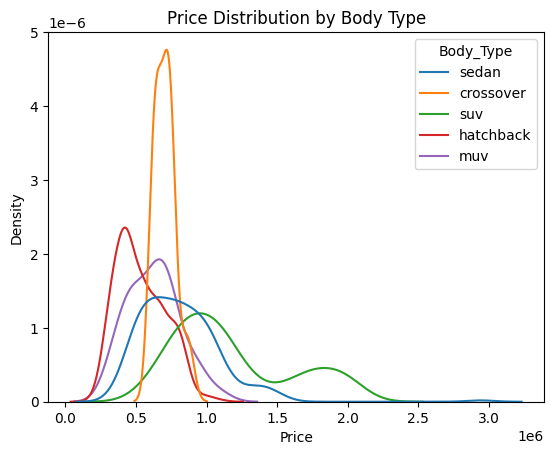

In [34]:
sns.kdeplot(data=df, x="Price", hue="Body_Type", common_norm=False)
plt.title("Price Distribution by Body Type")
plt.show()

#1
It seems sedans and suv's are the most expseive.

In [35]:
import statsmodels.formula.api as smf

model1 = smf.ols("Price ~ Seating_Capacity", data=df).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     5.075
Date:                Sat, 21 Mar 2026   Prob (F-statistic):             0.0245
Time:                        17:46:43   Log-Likelihood:                -13888.
No. Observations:                 976   AIC:                         2.778e+04
Df Residuals:                     974   BIC:                         2.779e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept          4.39e+05   1.35e+05  

In [36]:
model2 = smf.ols("Price ~ C(Seating_Capacity)", data=df).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     5.397
Date:                Sat, 21 Mar 2026   Prob (F-statistic):           0.000267
Time:                        17:46:57   Log-Likelihood:                -13880.
No. Observations:                 976   AIC:                         2.777e+04
Df Residuals:                     971   BIC:                         2.779e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

#2
In the linear regression, the slope on Seating Capacity is about 59,270, menaing price goes up by that amount ish with each new seat added.
However, when Seating Capacity is treated as categorical, the estimated price differences across seat counts are not evenly spaced (for example, 6-seat cars are much more expensive than 5-seat cars, while 8-seat cars are not).
This suggests that the relationship between seating capacity and price is not strictly linear.

In [37]:
df["Age"] = 2026 - df["Make_Year"]

#3
I did 3 here

In [38]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
import numpy as np

def make_poly(X, degree):
    X_poly = X.copy()
    for d in range(2, degree+1):
        X_poly[f"Age^{d}"] = X["Age"]**d
    return X_poly

X_base = df[["Age"]]
y = df["Price"]

kf = KFold(n_splits=10, shuffle=True, random_state=1)

results = {}

for d in range(1, 6):  # try degrees 1–5
    X_poly = make_poly(X_base.copy(), d)
    model = LinearRegression()
    mse = -cross_val_score(model, X_poly, y, cv=kf,
                           scoring="neg_mean_squared_error").mean()
    results[d] = mse

print(results)

{1: np.float64(97745760011.44075), 2: np.float64(97815319552.31636), 3: np.float64(97304076284.38507), 4: np.float64(96785385468.5646), 5: np.float64(95816293470.71298)}


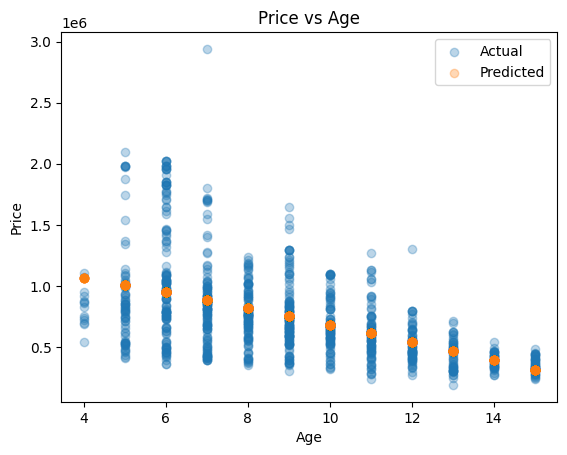

In [39]:
# Fit best model (example: degree = 2)
X_poly = make_poly(X_base.copy(), 2)
model = LinearRegression().fit(X_poly, y)

df["predicted"] = model.predict(X_poly)

# Plot
plt.scatter(df["Age"], df["Price"], alpha=0.3, label="Actual")
plt.scatter(df["Age"], df["predicted"], alpha=0.3, label="Predicted")
plt.legend()
plt.xlabel("Age")
plt.ylabel("Price")
plt.title("Price vs Age")
plt.show()

#4
It seems to be pretty goated!!! it made predictes that seem to be really close to tehe actuals, except for like maybe age 4. But that can be easily be expalined by the lack of data for the super young cars.

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1.
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models.
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


In [41]:
import pandas as pd #import statment

df = pd.read_csv("/content/heart_hw.csv")


In [42]:
control = df[df["transplant"] == "control"]["y"].mean()
treatment = df[df["transplant"] == "treatment"]["y"].mean()

ate = treatment - control

print("Control:", control)
print("Treatment:", treatment)
print("ATE:", ate)

Control: 0.11764705882352941
Treatment: 0.34782608695652173
ATE: 0.23017902813299232


#1
The survival rate is 11.8% (rounded up a little) for the control group and 34.8% for the treatment group, giving an ATE of 0.23. This means a transplant increases three-year survival probability by about 23 percentage points.

In [43]:
import statsmodels.formula.api as smf

model1 = smf.ols("y ~ C(transplant)", data=df).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     6.354
Date:                Sat, 21 Mar 2026   Prob (F-statistic):             0.0133
Time:                        18:50:07   Log-Likelihood:                -59.591
No. Observations:                 103   AIC:                             123.2
Df Residuals:                     101   BIC:                             128.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

#2
The intercept is 0.118, which represents the survival rate in the control group.The coefficient on the transplant variable is 0.230, which represents the difference in survival rates between the treatment and control groups. WOOP this exactly matches exactly the (ATE) nubmer we got in part 1, confirming that the regression reproduces the difference in group means.

In [44]:
model2 = smf.ols("y ~ C(transplant) + age", data=df).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.147
Model:                            OLS   Adj. R-squared:                  0.130
Method:                 Least Squares   F-statistic:                     8.602
Date:                Sat, 21 Mar 2026   Prob (F-statistic):           0.000357
Time:                        18:52:33   Log-Likelihood:                -54.558
No. Observations:                 103   AIC:                             115.1
Df Residuals:                     100   BIC:                             123.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

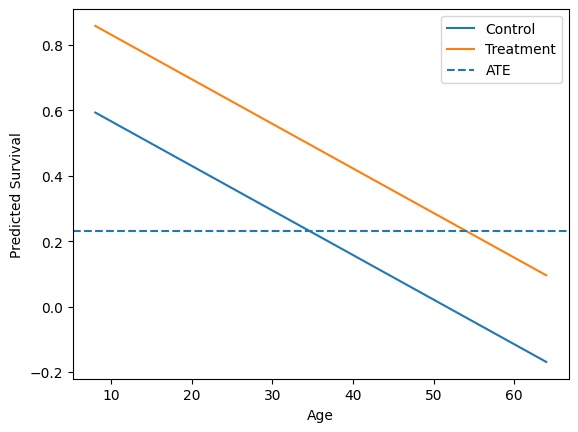

In [45]:
import numpy as np
import matplotlib.pyplot as plt

ages = np.linspace(df["age"].min(), df["age"].max(), 100)

# Predictions
pred_control = model2.params["Intercept"] + model2.params["age"] * ages
pred_treat = pred_control + model2.params["C(transplant)[T.treatment]"]

plt.plot(ages, pred_control, label="Control")
plt.plot(ages, pred_treat, label="Treatment")

plt.axhline(y=ate, linestyle="--", label="ATE")

plt.xlabel("Age")
plt.ylabel("Predicted Survival")
plt.legend()
plt.show()

#3
I plotted it! The ATE represents an average effect across all ages. As you can see for some ages (older usually) it underestiamtes, and for the younger adges it overesitamtes. This probs means that treatments vary greatly with age


In [46]:
model3 = smf.ols("y ~ C(transplant) * age", data=df).fit()
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.172
Model:                            OLS   Adj. R-squared:                  0.147
Method:                 Least Squares   F-statistic:                     6.839
Date:                Sat, 21 Mar 2026   Prob (F-statistic):           0.000310
Time:                        18:54:33   Log-Likelihood:                -53.033
No. Observations:                 103   AIC:                             114.1
Df Residuals:                      99   BIC:                             124.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

#4
When you do both age and transplant, u see that trasnplant is no longer cosntant across dif indivuals, leading to a neatgive interaction coeffeciton. (this number -0.0146 ) (so like i think as age increases the benefit of a trasnplant goes down) Which in my head makes sesne, cause major surgy when ur older carrys A TON of risks.
So younger, more benefit, older, poopy benefits.

In [47]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

y = df["y"]

# Model 1
X1 = df[["transplant"]]

pipe1 = Pipeline([
    ("prep", ColumnTransformer([
        ("cat", OneHotEncoder(drop="first"), ["transplant"])
    ])),
    ("model", LinearRegression())
])

# Model 2
X2 = df[["transplant", "age"]]

pipe2 = Pipeline([
    ("prep", ColumnTransformer([
        ("cat", OneHotEncoder(drop="first"), ["transplant"])
    ], remainder="passthrough")),
    ("model", LinearRegression())
])

# Model 3 (interaction manually)
df["interaction"] = (df["transplant"] == "treatment") * df["age"]
X3 = df[["transplant", "age", "interaction"]]

pipe3 = Pipeline([
    ("prep", ColumnTransformer([
        ("cat", OneHotEncoder(drop="first"), ["transplant"])
    ], remainder="passthrough")),
    ("model", LinearRegression())
])

def mse(pipe, X):
    return -cross_val_score(pipe, X, y, cv=10, scoring="neg_mean_squared_error").mean()

print(mse(pipe1, X1))
print(mse(pipe2, X2))
print(mse(pipe3, X3))

0.20970277289824915
0.19922806049232317
0.19609811380122735


#5
so it seems adding age improves accuracy rather than having transplant alone. Including the interaction between the two makes it go even higher (but like i mean in the sense that higer accucarcy causes lower msr)

#6
I'm lowkey afriad that it would never wanna give old people any organs. Which is bad because old people deserve to live too lol. It might also make it harder for middle aged poeple to get organs, which are usually people with families (and activly rasing kids). So those are my thoughts.

The model could benefit from taking mroe factors about other health status, smoking, drinking, mental health status. Lots of info. Does the person have a support system as well, as recovery process is not easy.

So its like really hard to use a model alone to "Decide" the best canidate.